## Module_3: *(Template)*

## Team Members:
*(Fill in)*

## Project Title:
*(Fill in)*



## Project Goal:
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

## Disease Background: 
*Fill in information and please note that this module is truncated and only has 5 bullets (instead of the 11 that you did for Module #1).*

* Prevalence & incidence
* Risk factors (genetic, lifestyle)
* Symptoms
* Standard of care treatment(s)
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)

## Data-Set: 
*Describe the data set(s) you will analyze. Cite the source(s) of the data -- in this case, these data have not yet been published and they are "hot off the press", having been recently generated by the Peirce-Cottler Lab in collaboration with the Kim Lab (https://uvahealth.com/findadoctor/John-Kim-1407155682) in the Division of Pulmonary and Critical Care at UVA. So the proper way to cite these data is:

"Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. 

Also, since we covered this in Lecture 1 of this Module in detail, describe how the data was collected -- What techniques were used? What units are the data measured in? Etc.*

## Data Analyis: 
*Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this Jupyter notebook can run your code to perform the analysis that you did, generate your figures, generate your .csv file, etc.). Show your graphs here, which should have proper labeles (e.g., x- and y-axes labels). Each graph you present should be thoroughly described by a caption so reader understands the data, why you are presenting it, and the main conclusion fromt the data.*
'''Module 3: count black and white pixels and compute the percentage of white pixels in a .jpg image and extrapolate points'''



,Filename,Depth (microns),White Pixels,Black Pixels,White %
0,C:\Users\omsin\Desktop\Comp BME\Module-3-Fibro...,15,51040,4143264,1.22
1,C:\Users\omsin\Desktop\Comp BME\Module-3-Fibro...,1000,120910,4073394,2.88
2,C:\Users\omsin\Desktop\Comp BME\Module-3-Fibro...,3000,83951,4110353,2.00
3,C:\Users\omsin\Desktop\Comp BME\Module-3-Fibro...,5300,151132,4043172,3.60
4,C:\Users\omsin\Desktop\Comp BME\Module-3-Fibro...,7000,59788,4134516,1.43
5,C:\Users\omsin\Desktop\Comp BME\Module-3-Fibro...,9900,99350,4094954,2.37


CSV file 'Percent_White_Pixels.csv' created.
Linear interpolation → Depth: 3500.0, White %: 2.35
Quadratic interpolation → Depth: 3500.0, White %: 2.19


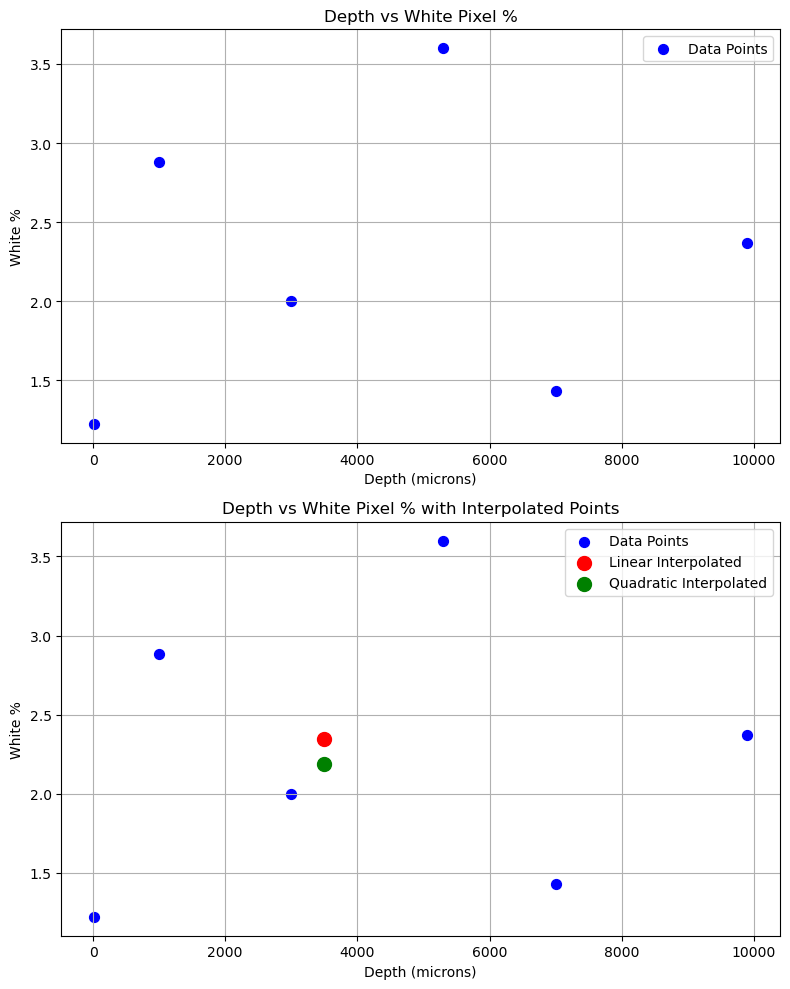

In [10]:
'''Module 3: count black and white pixels and compute the percentage of white pixels in a .jpg image and extrapolate points'''

# Module 3: Count black and white pixels, compute white %, and interpolate points

# -----------------------
# Import libraries
# -----------------------
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# -----------------------
# File paths and depths
# -----------------------
filenames = [
    r"C:\Users\omsin\Desktop\Comp BME\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010025.jpg",
    r"C:\Users\omsin\Desktop\Comp BME\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010063.jpg",    
    r"C:\Users\omsin\Desktop\Comp BME\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010065.jpg",
    r"C:\Users\omsin\Desktop\Comp BME\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010115.jpg",
    r"C:\Users\omsin\Desktop\Comp BME\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010158.jpg",
    r"C:\Users\omsin\Desktop\Comp BME\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010168.jpg",
]

depths = [15, 1000, 3000, 5300, 7000, 9900]

# -----------------------
# Lists to store results
# -----------------------
white_counts = []
black_counts = []
white_percents = []

# -----------------------
# Process images
# -----------------------
for filename in filenames:
    img = cv2.imread(filename, 0)  # grayscale
    if img is None:
        print(f"Error loading image: {filename}")
        continue

    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    white = np.count_nonzero(binary == 255)
    total_pixels = binary.size
    black = total_pixels - white

    white_counts.append(white)
    black_counts.append(black)
    white_percent = 100 * white / total_pixels
    white_percents.append(round(white_percent, 2))  # round for readability

# -----------------------
# Display results in a table
# -----------------------
df = pd.DataFrame({
    'Filename': filenames,
    'Depth (microns)': depths,
    'White Pixels': white_counts,
    'Black Pixels': black_counts,
    'White %': white_percents
})

display(df)  # Jupyter-friendly table

# -----------------------
# Save to CSV
# -----------------------
df.to_csv('Percent_White_Pixels.csv', index=False)
print("CSV file 'Percent_White_Pixels.csv' created.")

# -----------------------
# Interpolation
# -----------------------
interpolate_depth = float(input("Enter the depth (microns) to interpolate: "))

x = depths
y = white_percents

# Linear and Quadratic interpolation
i_linear = interp1d(x, y, kind='linear')
i_quadratic = interp1d(x, y, kind='quadratic')

linear_value = float(i_linear(interpolate_depth))
quadratic_value = float(i_quadratic(interpolate_depth))

print(f"Linear interpolation → Depth: {interpolate_depth}, White %: {linear_value:.2f}")
print(f"Quadratic interpolation → Depth: {interpolate_depth}, White %: {quadratic_value:.2f}")

# -----------------------
# Plotting
# -----------------------
depths_plot = depths + [interpolate_depth]
white_plot = white_percents + [linear_value]

fig, axs = plt.subplots(2, 1, figsize=(8, 10))

# Original data 
axs[0].scatter(depths, white_percents, color='blue', s=50, label='Data Points')
axs[0].set_title('Depth vs White Pixel %')
axs[0].set_xlabel('Depth (microns)')
axs[0].set_ylabel('White %')
axs[0].grid(True)
axs[0].legend()

# Data with interpolated points 
axs[1].scatter(depths, white_percents, color='blue', s=50, label='Data Points')
axs[1].scatter(interpolate_depth, linear_value, color='red', s=100, label='Linear Interpolated')
axs[1].scatter(interpolate_depth, quadratic_value, color='green', s=100, label='Quadratic Interpolated')
axs[1].set_title('Depth vs White Pixel % with Interpolated Points')
axs[1].set_xlabel('Depth (microns)')
axs[1].set_ylabel('White %')
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()


## Verify and validate your analysis: 
*Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., by comparing your analysis to a published paper).*

## Conclusions and Ethical Implications: 
*Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*Describe the limitations of your project. If you had more time to work on this, what would you do to explore further or refine your analysis?*

## References:
*You can use any format you like but provide the citations for facts that you referenced in this project notebook.*